# Pairs Trading & Statistical Arbitrage
## 07 - Monte Carlo Simulation & Stress Testing

This notebook evaluates the forward-looking risk profile of the V/MA pairs trading strategy through two complementary lenses: Monte Carlo simulation of future return paths and stress testing against specific historical crisis periods. Together these answer not just "how did the strategy perform" but "what should we expect from it going forward and how does it behave when markets break down."

### The Core Thesis
This strategy is not designed to generate outsized returns in calm markets. It is designed to be a stabilizing force - a market neutral return stream that holds its value or profits during the periods when most other strategies suffer most. The stress test results confirm this directly. The strategy is best understood as a complement to a more aggressive primary strategy rather than a standalone vehicle.

### Monte Carlo Simulation
We simulated 1000 possible future paths over a one year horizon using two methods:

**Normal simulation** draws daily returns from a fitted normal distribution using the historical mean and volatility. **Bootstrap simulation** resamples actual historical returns directly, preserving the true return distribution including fat tails and any autocorrelation structure.

The Jarque-Bera test strongly rejected normality in the return distribution (p-value essentially zero), meaning the normal simulation understates tail risk. Running both methods and comparing results gives a more honest picture.

| Method | 5th Percentile | Median | 95th Percentile |
|---|---|---|---|
| Normal simulation | -10.00% | 2.95% | 15.21% |
| Bootstrap simulation | -9.68% | 2.95% | 15.76% |

The near-identical results across both methods gives confidence that the simulation is stable and not overly sensitive to distributional assumptions. The median outcome of approximately 3% annualized is consistent with the historical backtest.

### Stress Test Results
The stress tests are the most important output in this notebook. A market neutral strategy should hold up or profit during market dislocations - and the results confirm exactly that.

| Period | Total Return | Sharpe | Max Drawdown |
|---|---|---|---|
| Full Period (2010-2026) | 43.81% | 0.34 | -13.44% |
| COVID Crash (Feb-Apr 2020) | +10.90% | 3.90 | -1.83% |
| Rate Shock (2022) | +5.33% | 0.75 | -3.28% |
| Q4 Selloff (2018) | -2.57% | -0.86 | -8.40% |
| Taper Tantrum (2013) | -2.05% | -0.35 | -4.68% |
| China Volatility (Aug 2015) | 0.00% | - | 0.00% |

The COVID crash result is striking - a 3.90 Sharpe and only -1.83% max drawdown during one of the fastest market selloffs in history. During COVID both V and MA were hit by the same demand shock to consumer spending, keeping the spread

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy import stats

# Reload prices
tickers = ["V", "MA"]
raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna()

log_returns = np.log(prices / prices.shift(1))

# Run base strategy to get returns
def run_strategy(prices, window=252, entry_threshold=2.0, cost_per_trade=0.0005):
    log_returns = np.log(prices / prices.shift(1))
    
    rolling_beta = pd.Series(index=prices.index, dtype=float)
    rolling_alpha = pd.Series(index=prices.index, dtype=float)
    
    for i in range(window, len(prices)):
        window_prices = prices.iloc[i-window:i]
        X = add_constant(window_prices["V"])
        y = window_prices["MA"]
        model = OLS(y, X).fit()
        rolling_beta.iloc[i] = model.params["V"]
        rolling_alpha.iloc[i] = model.params["const"]
    
    spread = prices["MA"] - (rolling_alpha + rolling_beta * prices["V"])
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    zscore = (spread - rolling_mean) / rolling_std
    
    signals = pd.Series(0.0, index=zscore.index)
    position = 0
    
    for i in range(len(zscore)):
        z = zscore.iloc[i]
        if np.isnan(z):
            signals.iloc[i] = 0
            continue
        if position == 0:
            if z < -entry_threshold:
                position = 1
            elif z > entry_threshold:
                position = -1
        elif position == 1:
            if z >= 0:
                position = 0
        elif position == -1:
            if z <= 0:
                position = 0
        signals.iloc[i] = position
    
    position_changes = signals.diff().abs()
    cost_series = position_changes * cost_per_trade * 4
    
    strategy_returns = (
        signals.shift(1) * log_returns["MA"] -
        signals.shift(1) * log_returns["V"] -
        cost_series
    ).dropna()
    
    return strategy_returns, signals, zscore

strategy_returns, signals, zscore = run_strategy(prices)

print(f"Strategy returns loaded: {len(strategy_returns)} days")
print(f"Mean daily return: {strategy_returns.mean():.6f}")
print(f"Daily vol: {strategy_returns.std():.6f}")

[*********************100%***********************]  2 of 2 completed


Strategy returns loaded: 4177 days
Mean daily return: 0.000105
Daily vol: 0.004867


Fitted distribution parameters:
  Daily mean (mu):    0.000105
  Daily vol (sigma):  0.004867
  Annualized return:  2.64%
  Annualized vol:     7.73%

Jarque-Bera normality test:
  Statistic:  35877.5099
  P-value:    0.0000
  Conclusion: Returns are non-normal


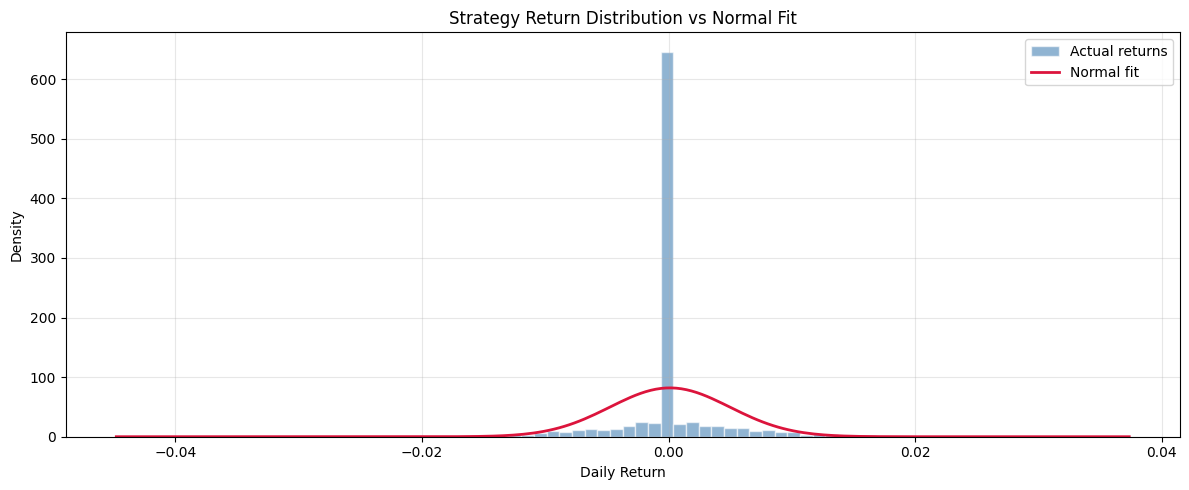

In [2]:
# Fit a normal distribution to strategy returns
# This gives us the parameters we need to simulate future paths
mu = strategy_returns.mean()
sigma = strategy_returns.std()

# Test whether returns are actually normal using Jarque-Bera test
jb_stat, jb_pvalue = stats.jarque_bera(strategy_returns.dropna())

print(f"Fitted distribution parameters:")
print(f"  Daily mean (mu):    {mu:.6f}")
print(f"  Daily vol (sigma):  {sigma:.6f}")
print(f"  Annualized return:  {mu * 252:.2%}")
print(f"  Annualized vol:     {sigma * np.sqrt(252):.2%}")
print(f"\nJarque-Bera normality test:")
print(f"  Statistic:  {jb_stat:.4f}")
print(f"  P-value:    {jb_pvalue:.4f}")
print(f"  Conclusion: {'Returns are non-normal' if jb_pvalue < 0.05 else 'Cannot reject normality'}")

# Plot return distribution vs normal fit
fig, ax = plt.subplots(figsize=(12, 5))
strategy_returns.hist(ax=ax, bins=80, density=True, color="steelblue", 
                      alpha=0.6, edgecolor="white", label="Actual returns")

x = np.linspace(strategy_returns.min(), strategy_returns.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="crimson", 
        linewidth=2, label="Normal fit")

ax.set_title("Strategy Return Distribution vs Normal Fit", fontsize=12)
ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# Monte Carlo simulation
# We simulate N possible future paths of the strategy
# Each path draws daily returns from the fitted distribution
# This gives us a range of possible outcomes rather than a single point estimate

n_simulations = 1000
n_days = 252  # simulate 1 year forward

np.random.seed(42)  # for reproducibility

# Simulate using both normal and bootstrapped returns
# Bootstrap resamples actual historical returns rather than assuming normality
# This preserves the actual return distribution including fat tails

# Method 1 - Normal simulation
normal_paths = np.zeros((n_days, n_simulations))
for i in range(n_simulations):
    daily_returns = np.random.normal(mu, sigma, n_days)
    normal_paths[:, i] = np.cumsum(daily_returns)

# Method 2 - Bootstrap simulation (resamples actual returns)
bootstrap_paths = np.zeros((n_days, n_simulations))
actual_returns = strategy_returns.dropna().values
for i in range(n_simulations):
    sampled_returns = np.random.choice(actual_returns, size=n_days, replace=True)
    bootstrap_paths[:, i] = np.cumsum(sampled_returns)

print(f"Simulated {n_simulations} paths over {n_days} trading days")
print(f"\nNormal simulation - 1 year outcomes:")
print(f"  5th percentile:  {normal_paths[-1].quantile(0.05) if hasattr(normal_paths[-1], 'quantile') else np.percentile(normal_paths[-1], 5):.2%}")
print(f"  Median:          {np.percentile(normal_paths[-1], 50):.2%}")
print(f"  95th percentile: {np.percentile(normal_paths[-1], 95):.2%}")
print(f"\nBootstrap simulation - 1 year outcomes:")
print(f"  5th percentile:  {np.percentile(bootstrap_paths[-1], 5):.2%}")
print(f"  Median:          {np.percentile(bootstrap_paths[-1], 50):.2%}")
print(f"  95th percentile: {np.percentile(bootstrap_paths[-1], 95):.2%}")

Simulated 1000 paths over 252 trading days

Normal simulation - 1 year outcomes:
  5th percentile:  -10.00%
  Median:          2.95%
  95th percentile: 15.21%

Bootstrap simulation - 1 year outcomes:
  5th percentile:  -9.68%
  Median:          2.95%
  95th percentile: 15.76%


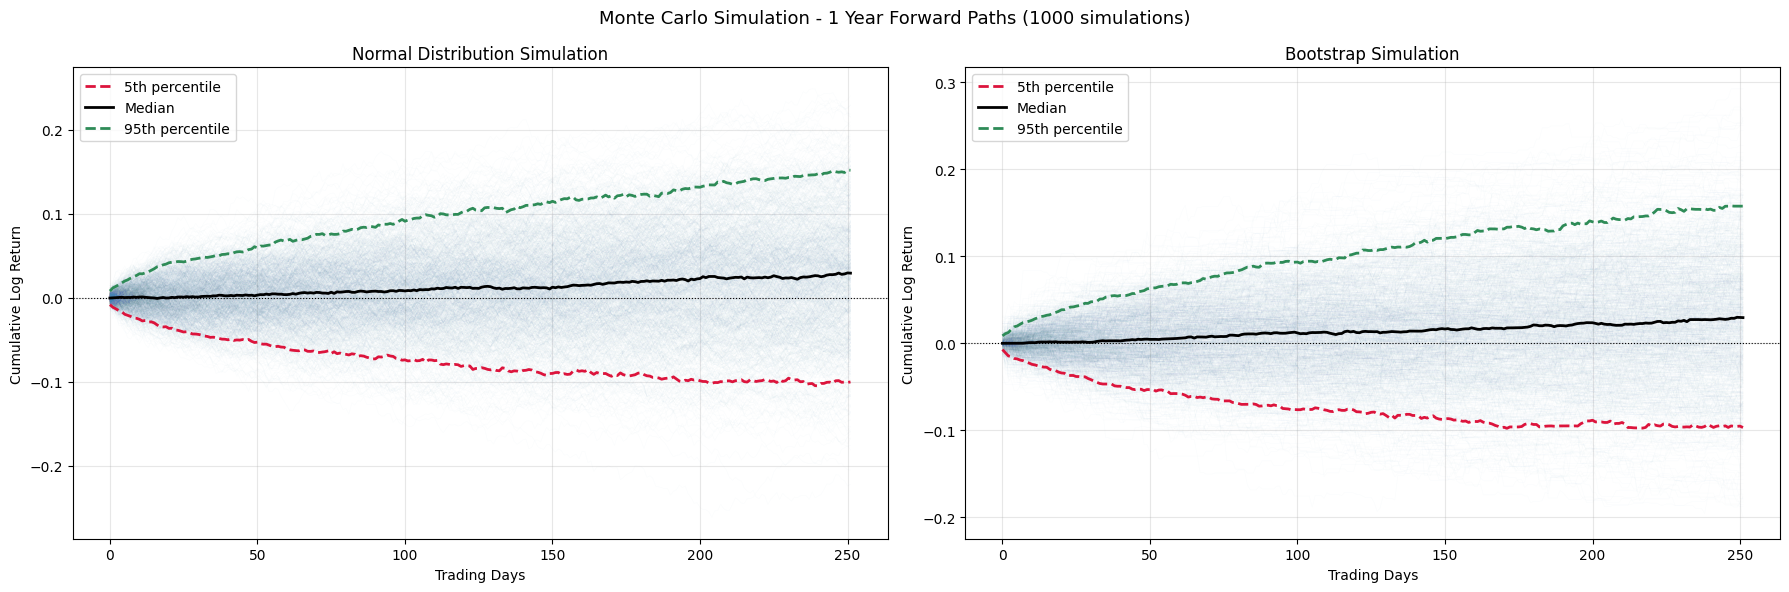

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, paths, title in [
    (axes[0], normal_paths, "Normal Distribution Simulation"),
    (axes[1], bootstrap_paths, "Bootstrap Simulation")
]:
    # Plot all paths in light grey
    for i in range(n_simulations):
        ax.plot(paths[:, i], color="steelblue", alpha=0.02, linewidth=0.5)
    
    # Plot percentile bands
    ax.plot(np.percentile(paths, 5, axis=1), color="crimson", 
            linewidth=2, linestyle="--", label="5th percentile")
    ax.plot(np.percentile(paths, 50, axis=1), color="black", 
            linewidth=2, label="Median")
    ax.plot(np.percentile(paths, 95, axis=1), color="seagreen", 
            linewidth=2, linestyle="--", label="95th percentile")
    
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Trading Days")
    ax.set_ylabel("Cumulative Log Return")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Monte Carlo Simulation - 1 Year Forward Paths (1000 simulations)", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# Stress testing - how did the strategy perform during specific crisis periods
# These are the tail risk events that Monte Carlo based on historical data may underestimate

stress_periods = {
    "COVID Crash (Feb-Apr 2020)": ("2020-02-01", "2020-04-30"),
    "Rate Shock (2022)": ("2022-01-01", "2022-12-31"),
    "China Volatility (Aug 2015)": ("2015-08-01", "2015-09-30"),
    "Q4 Selloff (2018)": ("2018-10-01", "2018-12-31"),
    "Taper Tantrum (2013)": ("2013-05-01", "2013-09-30")
}

def performance_summary(returns, label):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    cumulative = returns.cumsum()
    drawdown = cumulative - cumulative.cummax()
    max_dd = drawdown.min()
    total_return = returns.sum()
    print(f"\n{label}")
    print(f"  Total Return: {total_return:.2%}  Ann. Vol: {ann_vol:.2%}  Sharpe: {sharpe:.2f}  Max DD: {max_dd:.2%}")

print("=" * 55)
print("STRESS TEST RESULTS")
print("=" * 55)

# Full period for reference
performance_summary(strategy_returns, "Full Period (2010-2026)")

for period_name, (start, end) in stress_periods.items():
    period_returns = strategy_returns.loc[start:end]
    if len(period_returns) > 0:
        performance_summary(period_returns, period_name)

STRESS TEST RESULTS

Full Period (2010-2026)
  Total Return: 43.81%  Ann. Vol: 7.73%  Sharpe: 0.34  Max DD: -13.44%

COVID Crash (Feb-Apr 2020)
  Total Return: 10.90%  Ann. Vol: 11.36%  Sharpe: 3.90  Max DD: -1.83%

Rate Shock (2022)
  Total Return: 5.33%  Ann. Vol: 7.11%  Sharpe: 0.75  Max DD: -3.28%

China Volatility (Aug 2015)
  Total Return: 0.00%  Ann. Vol: 0.00%  Sharpe: 0.00  Max DD: 0.00%

Q4 Selloff (2018)
  Total Return: -2.57%  Ann. Vol: 11.98%  Sharpe: -0.86  Max DD: -8.40%

Taper Tantrum (2013)
  Total Return: -2.05%  Ann. Vol: 14.07%  Sharpe: -0.35  Max DD: -4.68%


VALUE AT RISK (Historical Simulation)

Confidence      1 Day           1 Week          1 Month        
-------------------------------------------------------
90%          -0.34%          -0.75%          -1.54%         
95%          -0.71%          -1.60%          -3.27%         
99%          -1.53%          -3.42%          -7.01%         


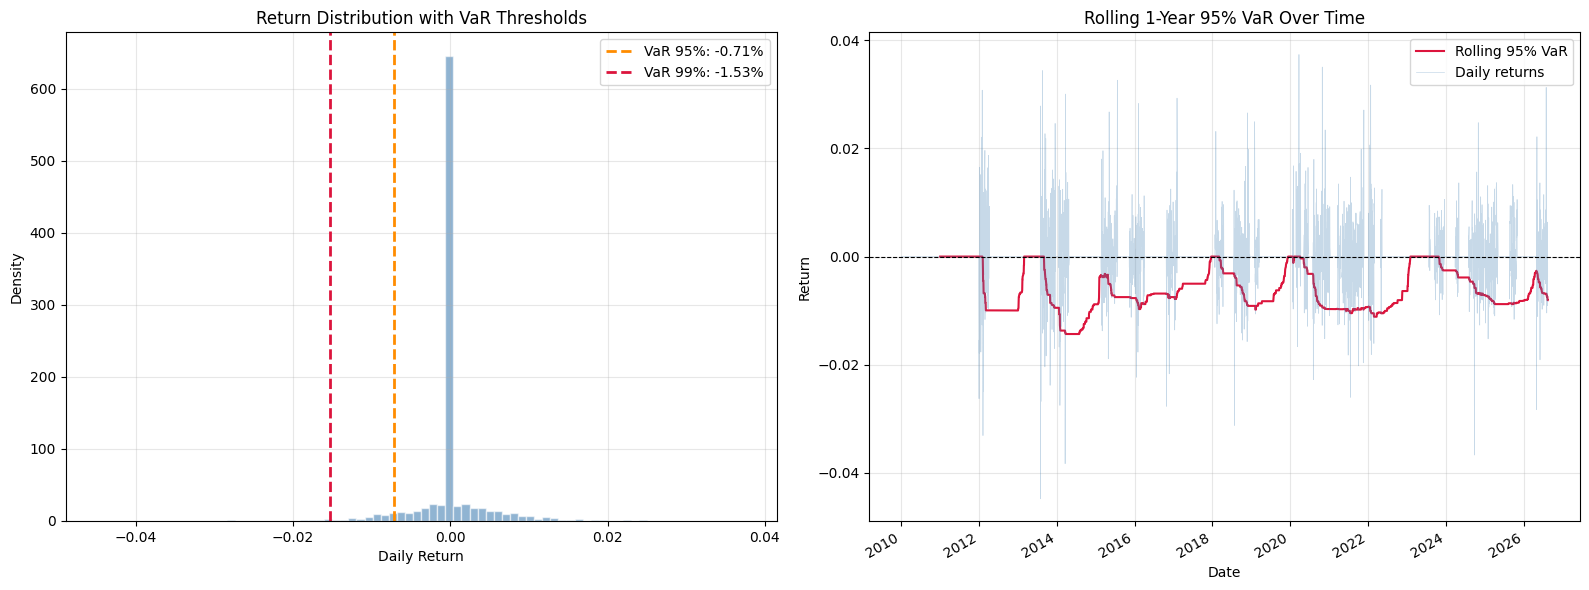

In [6]:
# Value at Risk analysis
# VaR answers: what is the maximum loss I should expect 
# with X% confidence over Y time horizon

confidence_levels = [0.90, 0.95, 0.99]
holding_periods = [1, 5, 21]  # 1 day, 1 week, 1 month

print("=" * 55)
print("VALUE AT RISK (Historical Simulation)")
print("=" * 55)
print(f"\n{'Confidence':<15} {'1 Day':<15} {'1 Week':<15} {'1 Month':<15}")
print("-" * 55)

for conf in confidence_levels:
    row = f"{conf:.0%}:<15"
    var_row = []
    for period in holding_periods:
        if period == 1:
            var = np.percentile(strategy_returns, (1 - conf) * 100)
        else:
            # Scale by square root of time
            var = np.percentile(strategy_returns, (1 - conf) * 100) * np.sqrt(period)
        var_row.append(f"{var:.2%}")
    print(f"{conf:.0%}          {var_row[0]:<15} {var_row[1]:<15} {var_row[2]:<15}")

# Plot VaR visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Return distribution with VaR marked
strategy_returns.hist(ax=ax1, bins=80, density=True, 
                      color="steelblue", alpha=0.6, edgecolor="white")

for conf, color in [(0.95, "darkorange"), (0.99, "crimson")]:
    var = np.percentile(strategy_returns, (1 - conf) * 100)
    ax1.axvline(var, color=color, linewidth=2, 
                linestyle="--", label=f"VaR {conf:.0%}: {var:.2%}")

ax1.set_title("Return Distribution with VaR Thresholds", fontsize=12)
ax1.set_xlabel("Daily Return")
ax1.set_ylabel("Density")
ax1.legend()
ax1.grid(alpha=0.3)

# Rolling 95% VaR over time
rolling_var = strategy_returns.rolling(252).quantile(0.05)
rolling_var.plot(ax=ax2, color="crimson", linewidth=1.5, label="Rolling 95% VaR")
strategy_returns.plot(ax=ax2, color="steelblue", alpha=0.3, linewidth=0.5, label="Daily returns")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Rolling 1-Year 95% VaR Over Time", fontsize=12)
ax2.set_ylabel("Return")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()